In [1]:
import json
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from joblib import Memory

base = next(
    p for r in [Path.cwd(), *Path.cwd().parents]
    for p in [r, r / "PRE_03_clasificacion_basica_imagenes"]
    if p.name == "PRE_03_clasificacion_basica_imagenes" and (p / "notebooks").is_dir()
)
submission = base / "submission"
submission.mkdir(exist_ok=True)
cache = Memory(base / "temp/cache", verbose=0)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
data, target = digits.data, digits.target
data.shape

(1797, 64)

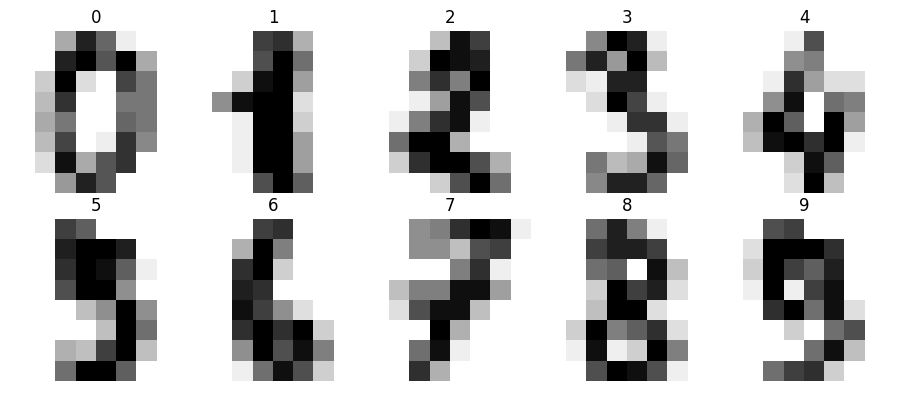

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(str(target[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
config = {"C": 10, "gamma": "scale", "kernel": "rbf",
          "test_size": 0.2, "random_state": 42, "sklearn": sklearn.__version__}
(submission / "config.json").write_text(json.dumps(config, indent=2))

x_train, x_test, y_train, y_test = train_test_split(
    data, target, test_size=config["test_size"],
    random_state=config["random_state"], stratify=target,
)

In [4]:
from sklearn.svm import SVC

@cache.cache
def entrenar(data, target, config):
    modelo = SVC(C=config["C"], kernel=config["kernel"], gamma=config["gamma"])
    modelo.fit(data, target)
    return modelo

estimator = entrenar(x_train, y_train, config)

In [5]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_pred = estimator.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy de prueba: {accuracy:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy de prueba: 0.9944
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       1.00      0.97      0.99        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



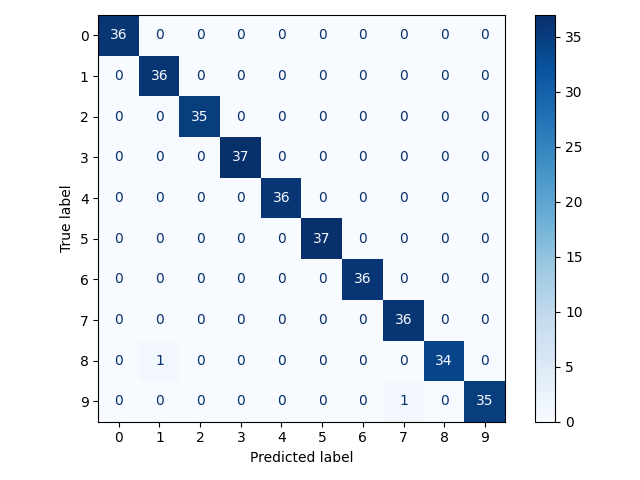

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.tight_layout()
plt.show()

In [7]:
with (submission / "estimator.pkl").open("wb") as archivo:
    pickle.dump(estimator, archivo)
pd.Series({"accuracy_prueba": accuracy}).to_csv(submission / "metricas.csv")